In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
def running_avg(x, n_windows):
    '''Computes a running average over x'''
    ws = int(len(x)/n_windows)  # size of each window
    return [np.sum(x[i*ws:i*ws+ws])/ws for i in range(int(len(x)/ws))]

In [22]:
out_dir = '/home/gianvito/Desktop/flatland_exp/debug_init_q_bis/exp_0'

cum_reward = np.load(os.path.join(out_dir, "cum_reward.npz"))
arrived_trains = np.load(os.path.join(out_dir, "arrived_trains.npz"))

In [12]:
cum_reward["x"].shape

(10000,)

In [11]:
arrived_trains["x"].shape

(7999,)

In [ ]:
out_dir = '/home/gianvito/Desktop/debug'

cum_reward = np.load(os.path.join(out_dir, "cum_reward.npz"))
arrived_trains = np.load(os.path.join(out_dir, "arrived_trains.npz"))

Text(0.5, 0, 'Episodes')

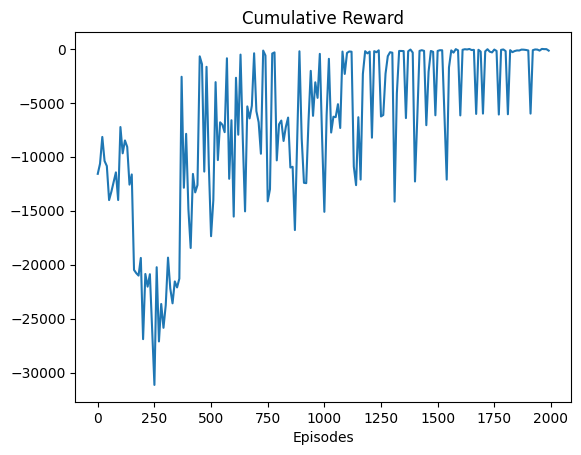

In [23]:
n_windows = 200
num_episodes = 2000
plt.plot(np.arange(0, num_episodes, num_episodes/n_windows), running_avg(cum_reward["x"][:num_episodes], n_windows))
plt.title('Cumulative Reward')
plt.xlabel('Episodes')

In [5]:
at = np.zeros(num_episodes)

at[:num_episodes-1] = arrived_trains["x"]
at[num_episodes-1] = arrived_trains["x"][num_episodes-2]

ValueError: could not broadcast input array from shape (2000,) into shape (1999,)

In [24]:
at = arrived_trains["x"][:num_episodes]

Text(0.5, 0, 'Episodes')

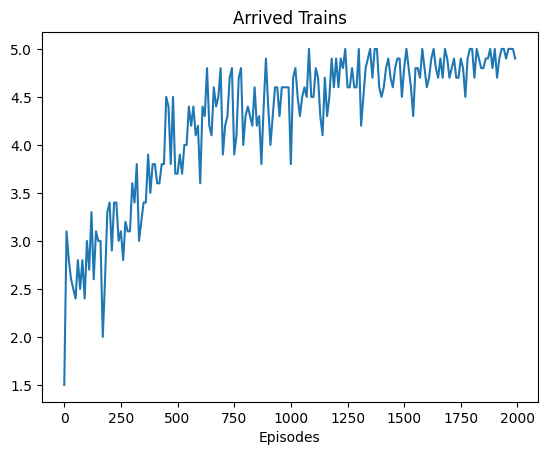

In [25]:
plt.plot(np.arange(0, num_episodes, num_episodes/n_windows), running_avg(at, n_windows))
plt.title('Arrived Trains')
plt.xlabel('Episodes')

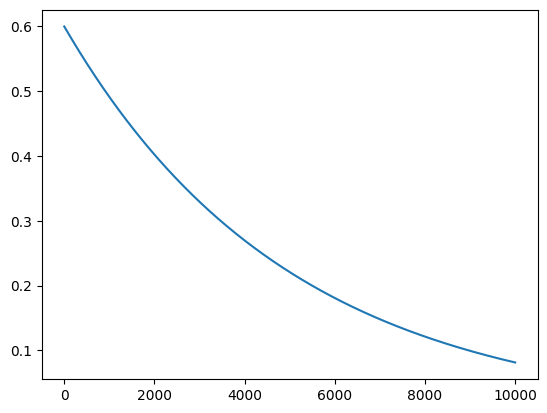

In [30]:
decay = 0.6 * (0.9998 ** np.arange(10_000))
plt.plot(decay)

# Error plot

In [5]:
list_dir = [
    # '/home/gianvito/Desktop/flatland_exp/15_agents_high_penalty/exp_0/seed_0',
    '/home/gianvito/Desktop/flatland_exp/15_agents_high_penalty/exp_0/seed_1',
    '/home/gianvito/Desktop/flatland_exp/15_agents_high_penalty/exp_0/seed_2',
    '/home/gianvito/Desktop/flatland_exp/15_agents_high_penalty/exp_0/seed_3',
    '/home/gianvito/Desktop/flatland_exp/15_agents_high_penalty/exp_0/seed_4',
]

In [6]:
num_episodes = 10_000
n_windows = 500

aggr_rew = np.zeros((len(list_dir), num_episodes))

for i, out_dir in enumerate(list_dir):
    cum_reward = np.load(os.path.join(out_dir, "cum_reward.npz"))
    aggr_rew[i, :] = cum_reward["x"][:num_episodes]

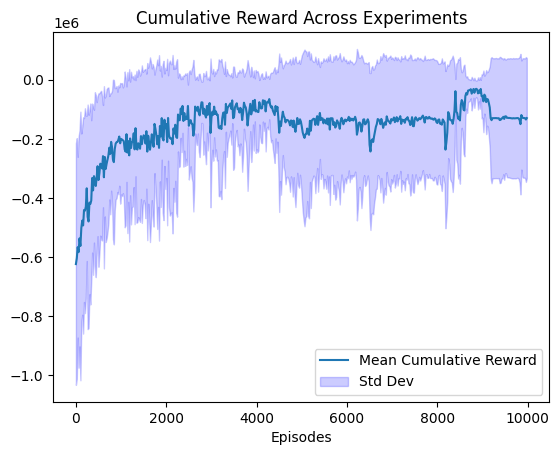

In [7]:
fig, ax = plt.subplots()

ax.plot(np.arange(0, num_episodes, num_episodes/n_windows),
        running_avg(np.mean(aggr_rew, axis=0), n_windows), label='Mean Cumulative Reward')
ax.fill_between(np.arange(0, num_episodes, num_episodes/n_windows),
                running_avg(np.mean(aggr_rew, axis=0) - np.std(aggr_rew, axis=0), n_windows),
                running_avg(np.mean(aggr_rew, axis=0) + np.std(aggr_rew, axis=0), n_windows),
                color='b', alpha=0.2, label='Std Dev')
ax.set_title('Cumulative Reward Across Experiments')
ax.set_xlabel('Episodes')
ax.legend()

In [8]:
aggr_trains = np.zeros((len(list_dir), num_episodes))
for i, out_dir in enumerate(list_dir):
    arrived_trains = np.load(os.path.join(out_dir, "arrived_trains.npz"))
    aggr_trains[i, :] = arrived_trains["x"][:num_episodes]

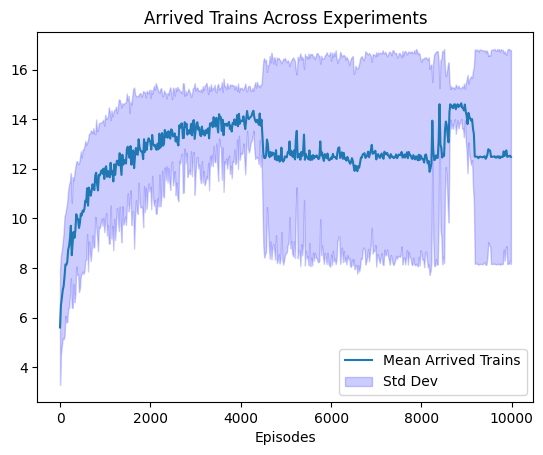

In [9]:
fig, ax = plt.subplots()

ax.plot(np.arange(0, num_episodes, num_episodes/n_windows),
        running_avg(np.mean(aggr_trains, axis=0), n_windows), label='Mean Arrived Trains')
ax.fill_between(np.arange(0, num_episodes, num_episodes/n_windows),
                running_avg(np.mean(aggr_trains, axis=0) - np.std(aggr_trains, axis=0), n_windows),
                running_avg(np.mean(aggr_trains, axis=0) + np.std(aggr_trains, axis=0), n_windows),
                color='b', alpha=0.2, label='Std Dev')
ax.set_title('Arrived Trains Across Experiments')
ax.set_xlabel('Episodes')
ax.legend()


In [8]:
path = '/home/gianvito/Desktop/flatland_exp/5_agents_with_init/exp_0/seed_0/trains_at_dest.npz'
trains_at_dest = np.load(path)
trains_at_dest["x"]

array([0, 1, 2, 3, 4])

# Eval

In [19]:
list_dir = [
    '/home/gianvito/Desktop/flatland_exp/5_agents_malf_hard/exp_0/seed_0',
    '/home/gianvito/Desktop/flatland_exp/5_agents_malf_hard/exp_0/seed_1',
    '/home/gianvito/Desktop/flatland_exp/5_agents_malf_hard/exp_0/seed_2',
    # '/home/gianvito/Desktop/flatland_exp/15_agents_with_init/exp_0/seed_3',
    # '/home/gianvito/Desktop/flatland_exp/15_agents_with_init/exp_0/seed_4',
]

num_agents = 5

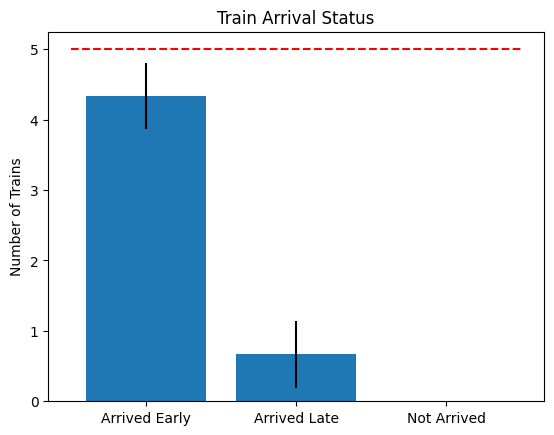

In [20]:
hist_data = np.zeros((len(list_dir), 3))
for idx, exp_dir in enumerate(list_dir):
    delays = np.load(os.path.join(exp_dir, "eval", "delays.npz"))
    delays = delays["x"]

    trains_at_dest = np.load(os.path.join(exp_dir, "eval", "trains_at_dest.npz"))
    trains_at_dest = trains_at_dest["x"]

    mask = np.zeros(num_agents).astype(bool)
    mask[trains_at_dest] = True
    arrived_negatives = np.sum(mask & (delays <= 0))
    arrived_positives = np.sum(mask & (delays > 0))
    not_arrived = np.sum(~mask)

    hist_data[idx, :] = [arrived_negatives, arrived_positives, not_arrived]

labels = ['Arrived Early', 'Arrived Late', 'Not Arrived']

fig, ax = plt.subplots()
ax.bar(labels, np.mean(hist_data, axis=0), yerr=np.std(hist_data, axis=0))
ax.hlines(num_agents, xmin=-0.5, xmax=2.5, color='r', linestyle='--', label='Total # of Trains')
ax.set_title('Train Arrival Status')
ax.set_ylabel('Number of Trains')
plt.show()